# Test completo di archivio, analisi e visualizzazione Sudoku

Questo notebook verifica l'intero flusso:

1. genera un nuovo Sudoku con soluzione unica;
2. lo salva nell'archivio;
3. lo ricarica dal file;
4. esegue l'analisi completa, che al primo accesso deve essere calcolata e salvata;
5. visualizza il risultato in tutti i modi disponibili;
6. richiede nuovamente la stessa analisi e verifica che venga restituita dalla cache in memoria.

Il notebook presuppone questi moduli nello stesso progetto:

- `sudoku_solver.py`
- `sudoku_archive.py`
- `sudoku_visualization.py`


In [1]:
import random
import time

import matplotlib.pyplot as plt
import pandas as pd

import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv
import sudoku_generator as sg

plt.rcParams["figure.figsize"] = (7, 7)


In [2]:
sudoku_ref_list = sa.list_sudokus(20, 'perceived_difficulty', 99)
sudoku_list = [sa.load_sudoku(x['name']) for x in sudoku_ref_list]
sudoku_analysis_list = [sa.analyse_puzzle_cached(x['grid'], x['name']) for x in sudoku_list]
sv.analyses_summary_dataframe(sudoku_analysis_list).sort_values('difficolta_percepita')

,nome,stato,difficolta,carico,difficolta_percepita,difficolta_massima,numero_step,step_non_banali,step_avanzati,solvibile_verificato
19,coach_ve_12,solved,Fondamentale,0,1.518419,1.0,51,0,0,True
18,coach_ve_11,solved,Fondamentale,0,1.526534,1.0,47,0,0,True
17,coach_e_4,solved,Fondamentale,0,1.527289,1.0,47,0,0,True
16,coach_e_3,solved,Fondamentale,0,1.578799,1.0,49,0,0,True
15,coach_e_2,solved,Fondamentale,0,1.579244,1.5,47,0,0,True
14,coach_e_9,solved,Fondamentale,0,1.580713,1.0,52,0,0,True
13,coach_e_8,solved,Fondamentale,0,1.616335,1.5,53,0,0,True
12,coach_e_1,solved,Fondamentale,0,1.643219,1.5,50,0,0,True
11,coach_m_9,solved,Fondamentale,0,1.732997,1.5,56,0,0,True
10,coach_m_0,solved,Fondamentale,0,1.752622,1.5,57,0,0,True


## 3. Caricamento del Sudoku

Il Sudoku viene ricaricato usando il nome assegnato. La griglia caricata viene confrontata con quella generata.


Sudoku caricato
ID: eee9493d086be4b82f32
Nome: coach_m_11
Percorso: sudoku_data\puzzles\eee9493d086be4b82f32.json


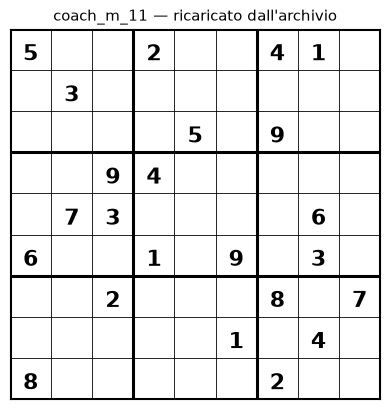

In [113]:
#loaded_info = sa.load_sudoku('coach_dev_1')
loaded_info = sa.load_last_sudoku()
loaded_puzzle = loaded_info["grid"]

print("Sudoku caricato")
print("ID:", loaded_info["id"])
print("Nome:", loaded_info["name"])
print("Percorso:", loaded_info["path"])

sv.draw_grid(
    loaded_puzzle,
    title=f"{loaded_info['name']} — ricaricato dall'archivio",
)
plt.show()


## 4. Prima analisi completa

Dato che il Sudoku è appena stato generato, la sua analisi non dovrebbe essere presente né nella cache in memoria né nell'archivio. La prima chiamata deve quindi:

1. eseguire il solver;
2. costruire la catena logica;
3. valutare la difficoltà;
4. salvare automaticamente l'analisi;
5. inserirla nella cache in memoria.


In [114]:
start = time.perf_counter()

first_result = sa.analyse_puzzle_cached(
    loaded_puzzle,
    name=loaded_info["name"],
)

first_elapsed = time.perf_counter() - start

print("Prima analisi completata")
print("Tempo:", round(first_elapsed, 4), "secondi")
print("Stato:", first_result["status"])
print("Valutazione:", first_result["grading"])
print("Numero di step:", len(first_result["chain"]))


Prima analisi completata
Tempo: 0.0034 secondi
Stato: solved
Valutazione: {'label': 'Fondamentale', 'max_difficulty': 1.5, 'max_level': 1, 'score': 0, 'workload_score': 0, 'perceived_difficulty': 1.9120092571339158, 'max_perceived_step': -0.1989700043360188, 'histogram': {1: 58, 2: 0, 3: 0, 4: 0, 5: 0}, 'status': 'solved', 'n_steps': 58, 'hardest_steps': 13, 'nontrivial_steps': 0, 'advanced_steps': 0}
Numero di step: 58


## 5. Visualizzazione della griglia risolta


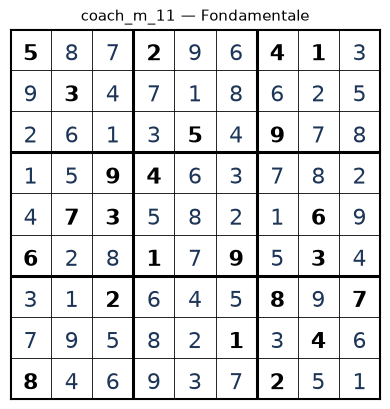

In [115]:
sv.draw_grid(
    first_result["solved_grid"],
    given_mask=(first_result["original"] != 0),
    title=(
        f"{first_result['name']} — "
        f"{first_result['grading']['label']}"
    ),
)
plt.show()


## 6. Catena di difficoltà

Mostra il livello di difficoltà usato a ogni step e il numero complessivo di passaggi per livello.


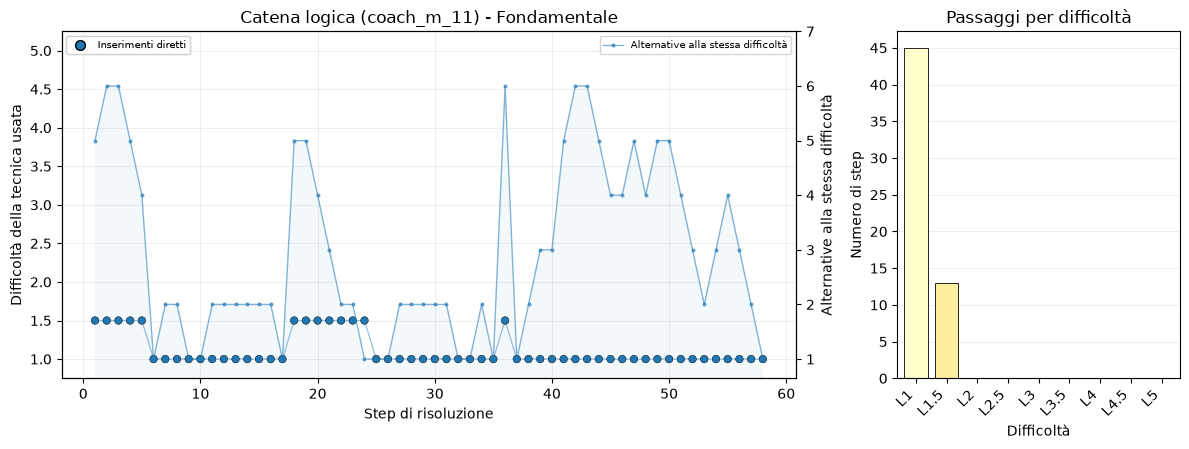

In [116]:
sv.plot_difficulty_chain(first_result)

## 7. Passaggio più difficile

Viene visualizzato lo stato della griglia in corrispondenza del passaggio con difficoltà massima.


Indice: 0
Step: 1
Tecnica: Hidden Single
Difficoltà: 1.5
Descrizione: Nel row che contiene R5C9, il numero 9 puo comparire solo li.


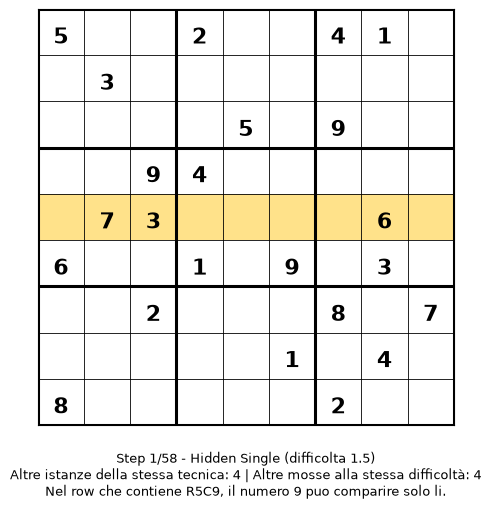

In [117]:
if first_result["chain"]:
    hardest_index = max(
        range(len(first_result["chain"])),
        key=lambda index: first_result["chain"][index]["difficulty"],
    )

    hardest_move = first_result["chain"][hardest_index]

    print("Indice:", hardest_index)
    print("Step:", hardest_move["step"])
    print("Tecnica:", hardest_move["technique"])
    print("Difficoltà:", hardest_move["difficulty"])
    print("Descrizione:", hardest_move["description"])

    sv.draw_step(first_result, hardest_index)
else:
    print("Nessun passaggio disponibile.")


## 8. Tabella completa della catena


In [118]:
chain_dataframe = sv.summary_dataframe(first_result)
chain_dataframe


,step,tecnica,famiglia,difficolta,n_alternative,descrizione
0,1,Hidden Single,Inserimenti diretti,1.5,36,"Nel row che contiene R5C9, il numero 9 puo com..."
1,2,Hidden Single,Inserimenti diretti,1.5,35,"Nel row che contiene R5C1, il numero 4 puo com..."
2,3,Hidden Single,Inserimenti diretti,1.5,37,"Nel row che contiene R5C7, il numero 1 puo com..."
3,4,Hidden Single,Inserimenti diretti,1.5,39,"Nel row che contiene R6C9, il numero 4 puo com..."
4,5,Hidden Single,Inserimenti diretti,1.5,40,"Nel row che contiene R8C5, il numero 2 puo com..."
5,6,Naked Single,Inserimenti diretti,1.0,42,La cella R5C5 ha un solo candidato possibile: 8.
6,7,Naked Single,Inserimenti diretti,1.0,42,La cella R5C4 ha un solo candidato possibile: 5.
7,8,Naked Single,Inserimenti diretti,1.0,39,La cella R5C6 ha un solo candidato possibile: 2.
8,9,Naked Single,Inserimenti diretti,1.0,33,La cella R6C5 ha un solo candidato possibile: 7.
9,10,Naked Single,Inserimenti diretti,1.0,30,La cella R6C7 ha un solo candidato possibile: 5.


## 9. Frequenza delle tecniche effettivamente usate


In [119]:
technique_counts = (
    chain_dataframe["tecnica"]
    .value_counts()
    .rename_axis("tecnica")
    .reset_index(name="numero_step")
)

technique_counts


,tecnica,numero_step
0,Naked Single,45
1,Hidden Single,13


## 10. Attività delle tecniche durante la risoluzione

Se `sudoku_visualization.py` contiene `plot_technique_activity`, viene mostrata la heatmap con:

- righe: tecniche;
- colonne: step;
- valori: numero di applicazioni disponibili in quello stato.

Le analisi devono contenere `applicable_by_technique` perché questa visualizzazione sia significativa.


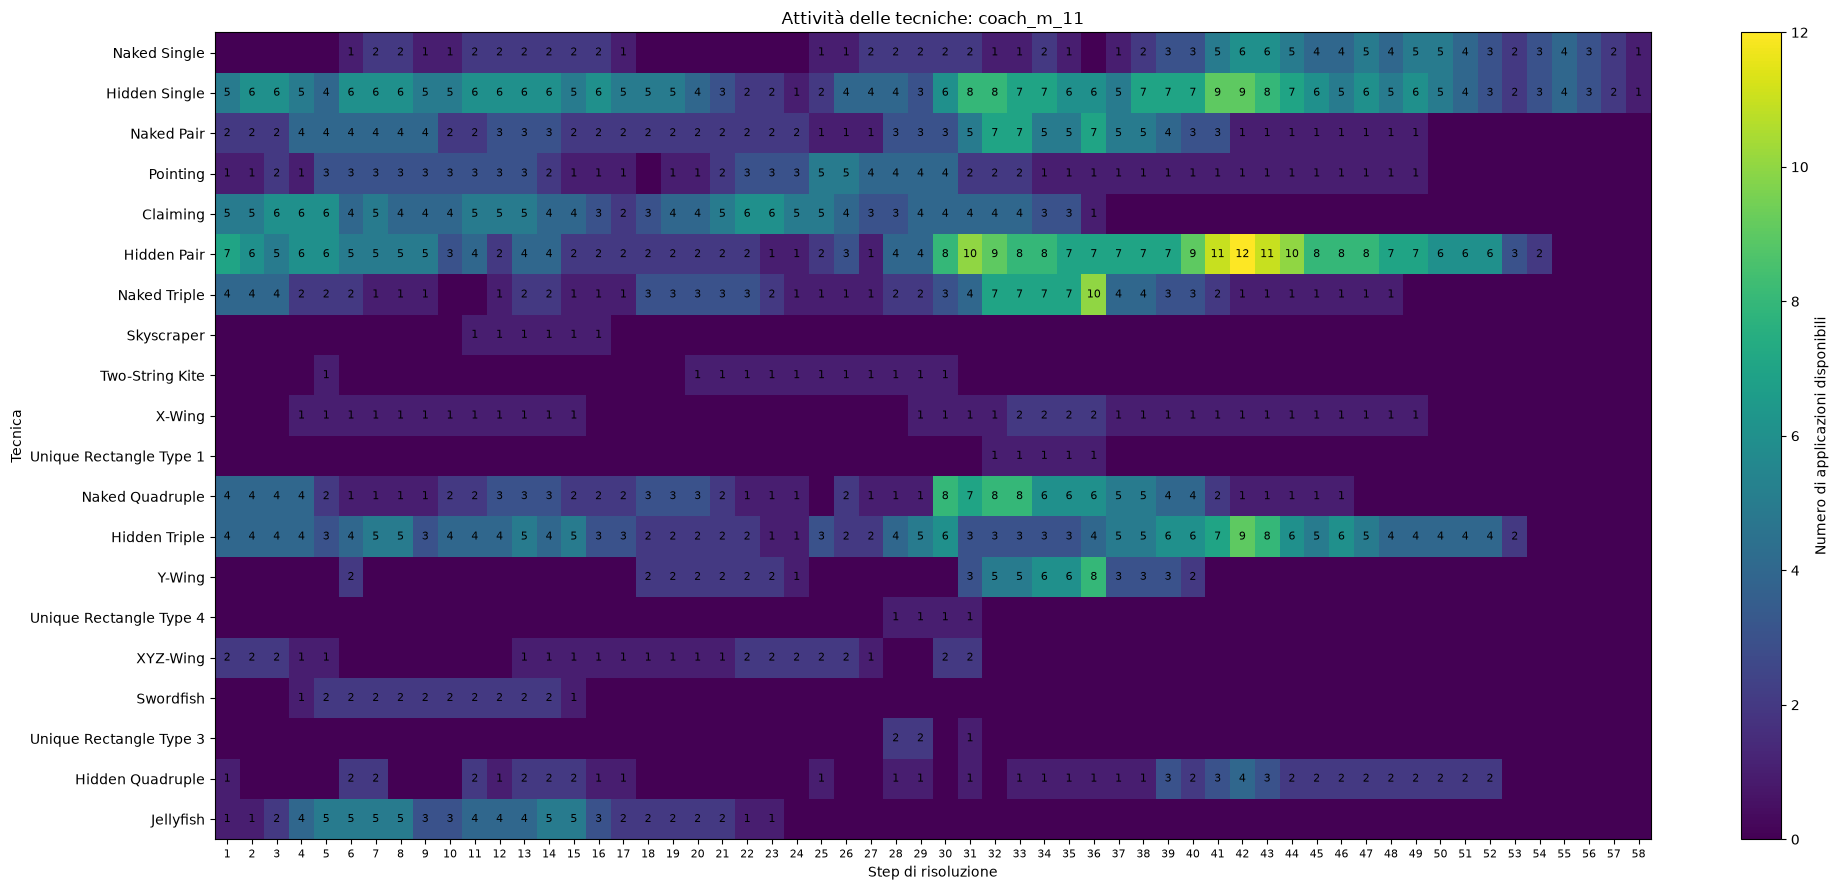

In [120]:
if hasattr(sv, "plot_technique_activity"):
    has_activity_data = any(
        "applicable_by_technique" in step
        for step in first_result["chain"]
    )

    if has_activity_data:
        sv.plot_technique_activity(first_result)
    else:
        print(
            "La funzione esiste, ma l'analisi non contiene "
            "'applicable_by_technique'. Aggiorna solve_and_log "
            "e incrementa ANALYSIS_VERSION."
        )
else:
    print(
        "plot_technique_activity non è presente in "
        "sudoku_visualization.py."
    )
